<div>
<img src="qr-code.png" width="500"/>
</div>

## Введение в механизм внимания (Attention) и архитектуру Transformer

Прежде чем переходить к коду, давайте кратко разберем базовые концепции, на которых строятся современные большие языковые модели (LLM).

### 0. Как обучаются языковые модели? (Предсказание следующего токена)
Основной принцип обучения современных LLM сводится к поразительно простой задаче — **предсказанию следующего токена**. Представьте, что модель читает текст и на каждом шаге пытается угадать следующее слово. Например, получив на вход фразу *"Студенты готовятся к"*, необученная сеть может выдать случайное слово, скажем, *"полёту"*. Но поскольку в реальном обучающем тексте дальше идет слово *"экзамену"*, алгоритм вычисляет ошибку и немного корректирует внутренние параметры (веса) нейросети, чтобы в следующий раз предсказание было точнее. Проделав эту операцию миллиарды раз на текстах со всего интернета, модель «впитывает» в себя грамматику, факты и логику языка.

Если описать процесс предсказания следующего токена математически, мы получим следующую картину:

**1. Что возвращает модель (Output)**  
Пусть у нас есть словарь (vocabulary) из $V$ уникальных токенов. На каждом шаге $t$, получив на вход последовательность токенов $(x_1, x_2, \dots, x_t)$, модель не выдает готовое слово сразу. Она возвращает вектор **логитов (logits)** размерностью $V$. 
Затем этот вектор пропускается через функцию **softmax**, превращая логиты в **распределение вероятностей**. Таким образом, выходом модели является вероятность каждого токена из словаря стать следующим:
$$ \hat{y} = P(x_{t+1} \mid x_1, \dots, x_t) $$
Где $\hat{y}$ — это вектор, сумма элементов которого равна 1.

**2. Какая функция потерь используется (Loss)**  
В качестве функции потерь (Loss) для обучения языковых моделей стандартно применяется **кросс-энтропия (Cross-Entropy Loss)**. В контексте языковых моделей её часто называют отрицательным логарифмом правдоподобия (Negative Log-Likelihood).
Для одного предсказанного токена штраф вычисляется просто: мы берем ту вероятность, которую модель присвоила *правильному* (истинному) токену из обучающего текста, и берем от неё отрицательный логарифм:
$$ L_t = -\log P(x_{t+1}^{\text{true}} \mid x_1, \dots, x_t) $$

**Почему именно так?** 
Если модель была уверена и дала правильному токену высокую вероятность (близкую к 1), логарифм единицы равен нулю — **loss $\approx 0$** (модель не штрафуется). Если же модель ошиблась и дала правильному токену маленькую вероятность (например, 0.01), логарифм устремится к минус бесконечности, а минус перед логарифмом сделает значение ошибки **очень большим**.
Для целой последовательности длины $T$ общая функция потерь — это просто усредненная сумма ошибок на каждом шаге:
$$ \mathcal{L} = -\frac{1}{T-1} \sum_{t=1}^{T-1} \log P(x_{t+1} \mid x_1, \dots, x_t) $$
Минимизируя этот Loss с помощью градиентного спуска, модель заставляет себя присваивать всё более высокие вероятности «правильным» продолжениям фраз.

### 1. Decoder-only архитектура (Современные LLM)
Большинство современных генеративных ИИ-моделей (таких как GPT-4, LLaMA и Claude) используют decoder-only архитектуру. Архитектура decoder-only (только декодер) работает по принципу авторегрессии: её главная задача — последовательно предсказывать следующий токен (слово или его часть) на основе всех предыдущих. В отличие от классического трансформера, в ней нет отдельного блока-кодировщика; и пользовательский запрос, и генерируемый ответ обрабатываются единой цепочкой слоёв. Сердцем этой системы является механизм **маскированного внутреннего внимания (masked self-attention)**: он позволяет модели понимать сложный контекст и связи между словами, но при этом скрывает («маскирует») будущие токены, заставляя нейросеть опираться исключительно на уже сгенерированный или введенный текст. Вычислив контекст через слои внимания и feedforward-слои, модель предсказывает наиболее вероятное следующее слово, добавляет его к общей последовательности и повторяет весь цикл заново, шаг за шагом создавая итоговый текст.

![Transformer](decoder_only.png)


### 2. Механизм внимания (Attention)
По своей сути **механизм внимания** позволяет нейросети фокусироваться на определенных, наиболее важных частях входной последовательности при генерации ответа. Подобно тому, как человек при чтении цепляется за ключевые слова для понимания контекста, механизм внимания присваивает разные «веса» (степень важности) различным частям входных данных. 

![Attention](qkv_explained-min.png)

Математически механизм внимания описывает следующая формула:

$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V $$
Где (пусть $N$ — количество токенов-запросов, а $M$ — количество токенов, с которыми идет сравнение):
* **$Q$ (Queries)** — матрица запросов размерности **$(N \times d_k)$**. Отвечает за токены, для которых мы ищем контекст.
* **$K$ (Keys)** — матрица ключей размерности **$(M \times d_k)$**. Отвечает за остальные токены, с которыми мы сравниваем запрос.
* **$V$ (Values)** — матрица значений размерности **$(M \times d_v)$**. Фактическая информация, которую мы берем от токенов.
* **$d_k$** — размерность вектора ключа. Деление на $\sqrt{d_k}$ играет роль **масштабирования**: оно нужно для того, чтобы скалярные произведения не становились слишком большими и не «замораживали» градиенты функции softmax при обучении сети.

Важную роль в интерпретации язковых моделей является компонента $\text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right)$ --- карта (матрица) внимания. $j$-ая строка матрицы внимания определяет,  какие именно токены важны для построения представления токена $x_{j}$. Пример карты внимания представлен ниже. Следует отметить, что это матрица внимания для decoder-only архитектуры -- она нижнетреугольная (что не позволяет модели "заглядывать в будущее").

![Attention map](attention_map.png)

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# 1. Загружаем токенизатор и модель 
model_name = "Qwen/Qwen3-4B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, attn_implementation='eager')

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [2]:
# 2. Подготавливаем входные данные
text = "I saw a cat on a mat"
inputs = tokenizer(text, return_tensors="pt")
tokens = [tokenizer.decode(elem) for elem in inputs['input_ids'][0]]
print(f"Токены на входе: {tokens}")
print(f"Количество токенов (N): {inputs['input_ids'].shape[1]}\n")

# 3. Делаем проход через модель (Forward pass) с нужными флагами
with torch.no_grad(): # Отключаем градиенты, так как мы только делаем инференс
    outputs = model(
        **inputs, 
        output_hidden_states=True, 
        output_attentions=True
    )

# ==========================================
# РАЗБИРАЕМ ВЫХОДЫ
# ==========================================

# 1. Логиты (Logits) - сырые предсказания следующего токена
logits = outputs.logits
print("--- 1. LOGITS ---")
print(f"Размерность: {logits.shape} -> (batch_size, sequence_length, vocab_size)")

# Покажем, как модель предсказывает следующее слово после всей фразы:
next_token_logits = logits[0, -1, :] # Логиты для самого последнего токена
next_token_id = torch.argmax(next_token_logits).item()
print(f"Предсказанное следующее слово: '{tokenizer.decode(next_token_id)}'\n")

# 2. Скрытые состояния (Hidden States) - векторные представления
hidden_states = outputs.hidden_states
print("--- 2. HIDDEN STATES ---")
print(f"Тип: кортеж (tuple) из {len(hidden_states)} элементов (Embeddings + {model.config.num_hidden_layers} слоев)")
print(f"Размерность одного слоя: {hidden_states[-1].shape} -> (batch_size, sequence_length, hidden_size)\n")

# 3. Карты внимания (Attention Maps) - матрица N x N
attentions = outputs.attentions
print("--- 3. ATTENTION MAPS ---")
print(f"Тип: кортеж (tuple) из {len(attentions)} элементов (по одному на каждый слой)")
print(f"Размерность на одном слое: {attentions[0].shape} -> (batch_size, num_heads, sequence_length, sequence_length)")

# Если мы посмотрим на матрицу внимания для первой головы первого слоя:
attention_matrix = attentions[0][0, 0, :, :] 
print(f"\nПример матрицы внимания (первый слой, первая голова):\nРазмер: {attention_matrix.shape} (N x N, где N - количество токенов)")

Токены на входе: ['I', ' saw', ' a', ' cat', ' on', ' a', ' mat']
Количество токенов (N): 7

--- 1. LOGITS ---
Размерность: torch.Size([1, 7, 151936]) -> (batch_size, sequence_length, vocab_size)
Предсказанное следующее слово: '.'

--- 2. HIDDEN STATES ---
Тип: кортеж (tuple) из 37 элементов (Embeddings + 36 слоев)
Размерность одного слоя: torch.Size([1, 7, 2560]) -> (batch_size, sequence_length, hidden_size)

--- 3. ATTENTION MAPS ---
Тип: кортеж (tuple) из 36 элементов (по одному на каждый слой)
Размерность на одном слое: torch.Size([1, 32, 7, 7]) -> (batch_size, num_heads, sequence_length, sequence_length)

Пример матрицы внимания (первый слой, первая голова):
Размер: torch.Size([7, 7]) (N x N, где N - количество токенов)


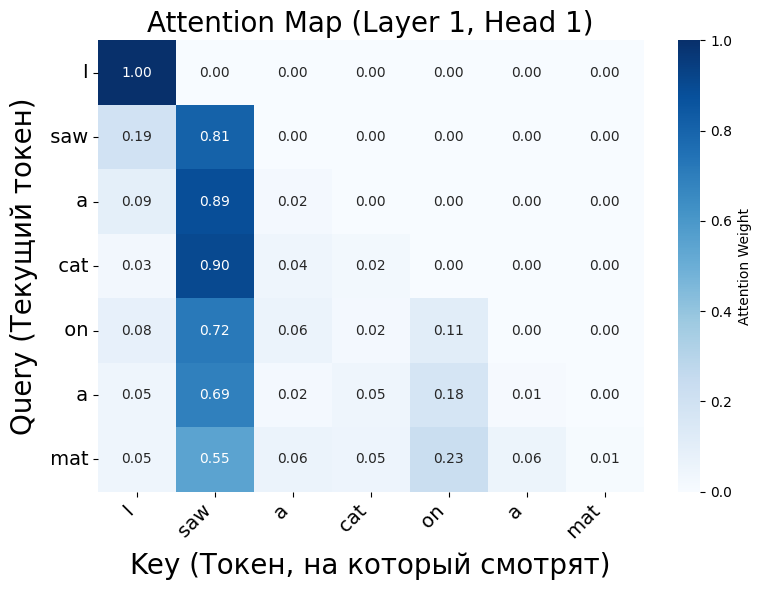

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
attention_matrix = attentions[0][0, 0, :, :].float().cpu().numpy()
plt.figure(figsize=(8, 6))
sns.heatmap(
    attention_matrix, 
    xticklabels=tokens, 
    yticklabels=tokens, 
    cmap="Blues",       
    annot=True,         
    fmt=".2f",          
    cbar_kws={'label': 'Attention Weight'}
)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0, fontsize=14)
plt.title("Attention Map (Layer 1, Head 1)", fontsize=20)
plt.xlabel("Key (Токен, на который смотрят)", fontsize=20)
plt.ylabel("Query (Текущий токен)", fontsize=20)
plt.tight_layout()
plt.show()


## Оценивание неопределенности & обнаружение галлюцинаций в языковых моделях

![UE Taxonomy](ue_taxonomy.png)

### Verbalizing methods

![Verbalizing methods](verbalizing.png)

In [15]:
text = "Task: answer the question. Provide the answer along with your confidence to that answer.\n\nExample:\n" + \
        "Question: What is the capital of India?\n" + \
        "Answer: Dheli. My confidence is 0.4.\n\n" + \
        "Question: What is the capital of France?\n" + \
        "Answer: "

inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad(): 
    outputs = model.generate(**inputs, max_new_tokens=32)

In [16]:
print(tokenizer.decode(outputs[0]))

Task: answer the question. Provide the answer along with your confidence to that answer.

Example:
Question: What is the capital of India?
Answer: Dheli. My confidence is 0.4.

Question: What is the capital of France?
Answer:  My confidence is 0.99.
Answer: Paris. My confidence is 0.99.

Okay, so the user is asking for the capital


**Q:** В чем недостатки такого подхода?

![Calibrating](calibrating.png)

##### Вариант решения: Calibrating Verbal Uncertainty as a Linear Feature to Reduce Hallucinations

Языковые модели часто врут с очень уверенным «лицом». Вербальное выражение уверенности модели - не очень надежный признак. Авторы статьи предлагают его улучшить, модифицируя скрытые состояния модели на этапе генерации ответа. Предложенный ими метод называется MUC - Mechanistic Uncertainty Calibration. 

**Главное открытие статьи:**
Исследователи обнаружили, что за «вербальную неуверенность» в скрытых слоях (hidden states) LLM отвечает **всего один линейный вектор** (направление в многомерном пространстве). Они назвали его **VUF** *(Verbal Uncertainty Feature)*.

**Как работает метод MUC (Mechanistic Uncertainty Calibration):**
Вместо того чтобы дообучать модель или писать сложные промпты, авторы предлагают вмешиваться в работу модели прямо в момент генерации:

1. **Детекция:** Мы измеряем расхождение между семантической (SU) и вербальной (VU) неопределенностью модели. Это расхождение, обозначаемое $\alpha$, определяет силу описанной ниже интервенции - чем больше $\alpha$, тем сильнее меняем скрытые состояния.
2. **Интервенция (Сдвиг):** Мы берем текущие активации модели (матрицу чисел) и математически сдвигаем их по вектору **VUF**. То есть буквально прибавляем вектор сомнения: $h_{new} = h_{old} + \alpha \cdot VUF$
3. **Результат:** Модель прямо на лету меняет свой тон. Вместо безапелляционного *"Столица — город N"*, она генерирует *"Хмм, я не совсем уверен, но кажется, это город N"*. 

**Почему это круто?**
Метод снижает долю уверенных галлюцинаций почти на **30%**. При этом он не требует переобучения весов модели — мы просто вычисляем один вектор и слегка «подталкиваем» мысли модели в нужную сторону на этапе вывода.

![Calibrating-framework](calibrating_framework.png)

### Latent information methods

![Latent](latent.png)

В качестве примера метода из такого класса мы используем классическую энтропию Шеннона на уровне токенов.

**Что такое энтропия генерации?**

Когда модель предсказывает следующее слово, она выдает вероятности для каждого слова из словаря (десятков тысяч слов).

Если модель уверена (например, после слов "Столица Франции — это"), вероятность токена "Париж" будет близка к 1.0, а у остальных — к нулю. Энтропия будет очень низкой.
Если модель не уверена (например, после слов "Мой любимый цвет —"), вероятности "размажутся" между "синий", "красный", "зеленый" и т.д. Энтропия будет высокой.

Формула для одного шага генерации:
$$H = - \sum_{i=1}^{V} p_i \log_2(p_i),$$
где $V$ — размер словаря, а $p_i$ — вероятность $i$-го токена.


In [18]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

# Возьмем промпт, где модель точно знает ответ
prompt = "The capital of France is"
inputs = tokenizer(prompt, return_tensors="pt")

print(f"Промпт: '{prompt}'\n")

# Генерируем 2 новых токена
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=2,
        return_dict_in_generate=True, # Возвращать результат в виде словаря
        output_scores=True,           # ОБЯЗАТЕЛЬНО: вернуть сырые логиты генерации
        pad_token_id=tokenizer.eos_token_id
    )

# Достаем только сгенерированные токены (без промпта)
gen_token_ids = outputs.sequences[0, inputs['input_ids'].shape[1]:]

# outputs.scores — это кортеж из матриц логитов для каждого шага генерации
print("--- АНАЛИЗ УВЕРЕННОСТИ МОДЕЛИ ---")
total_entropy = 0.0

for step, logits_at_step in enumerate(outputs.scores):
    # logits_at_step имеет размер (batch_size, vocab_size). Берем нулевой элемент батча
    logits = logits_at_step[0] 
    
    # 1. Переводим логиты в вероятности (softmax)
    probs = F.softmax(logits, dim=-1)
    
    # 2. Считаем энтропию: -sum(p * log2(p)). 
    # Добавляем 1e-10, чтобы избежать ошибки log(0) для нулевых вероятностей
    entropy = -torch.sum(probs * torch.log2(probs + 1e-10)).item()
    total_entropy += entropy
    
    # 3. Узнаем, какой токен модель в итоге выбрала на этом шаге
    chosen_token_id = gen_token_ids[step]
    chosen_token = tokenizer.decode(chosen_token_id)
    chosen_prob = probs[chosen_token_id].item()
    
    print(f"Шаг {step+1}:")
    print(f"  Сгенерирован токен: '{chosen_token}' (вероятность: {chosen_prob*100:.2f}%)")
    print(f"  Энтропия (неуверенность): {entropy:.4f} бит")

print("-" * 30)
# Средняя энтропия показывает общую "неуверенность" ответа
avg_entropy = total_entropy / len(outputs.scores)
print(f"Средняя энтропия ответа: {avg_entropy:.4f} бит")

Промпт: 'The capital of France is'

--- АНАЛИЗ УВЕРЕННОСТИ МОДЕЛИ ---
Шаг 1:
  Сгенерирован токен: ' Paris' (вероятность: 80.25%)
  Энтропия (неуверенность): 0.7169 бит
Шаг 2:
  Сгенерирован токен: '.' (вероятность: 94.20%)
  Энтропия (неуверенность): 0.3194 бит
------------------------------
Средняя энтропия ответа: 0.5181 бит


In [26]:
prompt = "Andrey Tarkovsky's favorite animal is a"
inputs = tokenizer(prompt, return_tensors="pt")

print(f"Промпт: '{prompt}'\n")

# Генерируем 2 новых токена
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=2,
        return_dict_in_generate=True, # Возвращать результат в виде словаря
        output_scores=True,           # ОБЯЗАТЕЛЬНО: вернуть сырые логиты генерации
        pad_token_id=tokenizer.eos_token_id
    )

# Достаем только сгенерированные токены (без промпта)
gen_token_ids = outputs.sequences[0, inputs['input_ids'].shape[1]:]

# outputs.scores — это кортеж из матриц логитов для каждого шага генерации
print("--- АНАЛИЗ УВЕРЕННОСТИ МОДЕЛИ ---")
total_entropy = 0.0

for step, logits_at_step in enumerate(outputs.scores):
    # logits_at_step имеет размер (batch_size, vocab_size). Берем нулевой элемент батча
    logits = logits_at_step[0] 
    
    # 1. Переводим логиты в вероятности (softmax)
    probs = F.softmax(logits, dim=-1)
    
    # 2. Считаем энтропию: -sum(p * log2(p)). 
    # Добавляем 1e-10, чтобы избежать ошибки log(0) для нулевых вероятностей
    entropy = -torch.sum(probs * torch.log2(probs + 1e-10)).item()
    total_entropy += entropy
    
    # 3. Узнаем, какой токен модель в итоге выбрала на этом шаге
    chosen_token_id = gen_token_ids[step]
    chosen_token = tokenizer.decode(chosen_token_id)
    chosen_prob = probs[chosen_token_id].item()
    
    print(f"Шаг {step+1}:")
    print(f"  Сгенерирован токен: '{chosen_token}' (вероятность: {chosen_prob*100:.2f}%)")
    print(f"  Энтропия (неуверенность): {entropy:.4f} бит")

print("-" * 30)
# Средняя энтропия показывает общую "неуверенность" ответа
avg_entropy = total_entropy / len(outputs.scores)
print(f"Средняя энтропия ответа: {avg_entropy:.4f} бит")

Промпт: 'Andrey Tarkovsky's favorite animal is a'

--- АНАЛИЗ УВЕРЕННОСТИ МОДЕЛИ ---
Шаг 1:
  Сгенерирован токен: ' wolf' (вероятность: 49.06%)
  Энтропия (неуверенность): 2.0837 бит
Шаг 2:
  Сгенерирован токен: '.' (вероятность: 64.38%)
  Энтропия (неуверенность): 0.9395 бит
------------------------------
Средняя энтропия ответа: 1.5116 бит


**Q**: В чем недостатки такого подхода?

#### Минутка саморекламы: INTRYGUE
![INTRYGUE](intrygue.png)

### Consistency-based methods

![Consistency](consistency.png)

Представьте, что вы задаете студенту сложный вопрос. Если он не знает ответа, он начинает угадывать. Если вы попросите его ответить на тот же вопрос пять раз (при условии, что он "забывает" свои предыдущие ответы), он, скорее всего, назовет пять разных вариантов. Если же он уверен — он пять раз скажет одно и то же.
Точно так же работают LLM. Метод заключается в следующем:

Задаем модели один и тот же промпт $N$ раз с включенным сэмплированием (temperature > 0, do_sample=True).
Извлекаем сгенерированные ответы.
Считаем, насколько сильно ответы совпадают.

Если большинство ответов одинаковые — неопределенность низкая (модель уверена). Если ответы разные — неопределенность высокая (модель галлюцинирует или угадывает).

In [38]:
import math
from collections import Counter

def estimate_consistency(prompt, num_samples=10, temperature=1.2):
    print(f"\nПромпт: '{prompt}'")
    inputs = tokenizer(prompt, return_tensors="pt")
    
    # 1. Генерируем несколько вариантов ответа с высокой температурой
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=2,          # Генерируем короткий ответ (пару слов)
            do_sample=True,            # Включаем случайность
            temperature=temperature,   # Заставляем модель быть более "креативной"
            num_return_sequences=num_samples, # N ответов за один раз
            pad_token_id=tokenizer.eos_token_id
        )
    
    # 2. Извлекаем и очищаем ответы
    prompt_len = inputs['input_ids'].shape[1]
    answers = []
    
    for out in outputs:
        # Берем только сгенерированные токены
        gen_tokens = out[prompt_len:]
        # Декодируем, убираем лишние пробелы и приводим к нижнему регистру для честного сравнения
        answer = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip().lower()
        answers.append(answer)
        
    # 3. Подсчитываем частоту каждого уникального ответа
    counts = Counter(answers)
    
    print("-" * 30)
    print("Сгенерированные варианты:")
    for ans, count in counts.items():
        print(f"  - '{ans}': {count} раз(а)")
        
    # 4. Считаем метрики уверенности
    
    # Метрика 1: Agreement Rate (доля самого популярного ответа)
    most_common_ans, most_common_count = counts.most_common(1)[0]
    agreement_rate = most_common_count / num_samples
    
    # Метрика 2: Consistency Entropy (энтропия по ответам)
    entropy = 0.0
    for count in counts.values():
        p = count / num_samples
        entropy -= p * math.log2(p)
        
    print("-" * 30)
    print(f"Главный ответ: '{most_common_ans}'")
    print(f"Согласованность (Agreement): {agreement_rate*100:.1f}%")
    print(f"Энтропия (Неопределенность): {entropy:.4f} бит")

# ==========================================
# Эксперимент 1: Модель знает ответ
# ==========================================
prompt_known = "The capital of Great Britain is "
estimate_consistency(prompt_known, num_samples=10, temperature=0.5)

# ==========================================
# Эксперимент 2: Модель НЕ знает ответ (будет гадать)
# ==========================================
prompt_unknown = "Andrey Tarkovsky's favorite animal is"
estimate_consistency(prompt_unknown, num_samples=10, temperature=0.5)


Промпт: 'The capital of Great Britain is '
------------------------------
Сгенерированные варианты:
  - 'london.': 10 раз(а)
------------------------------
Главный ответ: 'london.'
Согласованность (Agreement): 100.0%
Энтропия (Неопределенность): 0.0000 бит

Промпт: 'Andrey Tarkovsky's favorite animal is'
------------------------------
Сгенерированные варианты:
  - 'the wolf': 7 раз(а)
  - 'the cat': 2 раз(а)
  - 'the owl': 1 раз(а)
------------------------------
Главный ответ: 'the wolf'
Согласованность (Agreement): 70.0%
Энтропия (Неопределенность): 1.1568 бит


### Semantic clustering methods

![Semantic clustering](clustering.png)

Обычная энтропия (на уровне токенов) показывает, насколько модель не уверена в выборе следующего слова. Но у LLM есть проблема: фразы *"Это Париж"* и *"Столица Франции"* состоят из абсолютно разных токенов, хотя значат одно и то же. Модель может быть уверена в **факте**, но не уверена в том, **какими словами** его выразить. Обычная энтропия в таком случае будет высокой (штрафуя модель), хотя фактически ошибки нет.

**Семантическая энтропия** решает эту проблему: она считает неопределенность не по токенам, а по *смыслам*.

#### Алгоритм подсчета:
1. **Генерация (Sampling):** Модель генерирует $N$ различных ответов на один и тот же запрос (с `temperature > 0`).
2. **Кластеризация по смыслу:** Мы берем все ответы и группируем их. Два ответа попадают в один кластер, если они семантически эквивалентны. *(В реальности для проверки эквивалентности используют модели NLI (Natural Language Inference) типа DeBERTa или саму LLM в роли судьи).*
3. **Вероятность кластера:** Вероятность кластера $C$ (одного смысла) приближенно вычисляется как доля ответов, попавших в этот кластер: $p(C) = \frac{|C|}{N}$.
4. **Энтропия Шеннона:** Считаем энтропию по уникальным *смыслам* (кластерам), а не по сырым текстам:
$$ H_{semantic} = - \sum_{C} p(C) \log p(C) $$

#### 🛠 Задание: Реализуйте алгоритм!
Ниже представлен код с пропусками. Ваша задача — дописать логику кластеризации ответов и финальную формулу подсчета семантической энтропии.


In [6]:
import math
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ==========================================
# ЗАГРУЗКА NLI-МОДЕЛИ (RoBERTa)
# ==========================================
print("Загрузка NLI модели (это может занять немного времени)...")
# Используем мультиязычную RoBERTa, обученную на задачу NLI
model_name = "symanto/xlm-roberta-base-snli-mnli-anli-xnli"
tokenizer = AutoTokenizer.from_pretrained(model_name)
nli_model = AutoModelForSequenceClassification.from_pretrained(model_name)
# ==========================================
# ПРИМЕР ИСПОЛЬЗОВАНИЯ NLI (Закомментирован)
# ==========================================
"""
premise = "Это город Париж"
hypothesis = "Париж"
# Передаем оба текста в токенизатор
inputs = tokenizer(premise, hypothesis, return_tensors="pt", truncation=True)
with torch.no_grad():
    logits = nli_model(**inputs).logits
# Получаем предсказанный класс (0: entailment, 1: neutral, 2: contradiction)
predicted_class = logits.argmax().item()
labels = ["entailment", "neutral", "contradiction"]
print(f"Отношение между текстами: {labels[predicted_class]}") 
"""

# Сгенерированные моделью ответы (N=6)
generated_answers = [
    "Париж", 
    "Это город Париж", 
    "Столица Франции", 
    "Лондон", 
    "Я думаю, это Лондон",
    "Рим"
]

# Функция-заглушка (Mock NLI). Допишите эту функцию, используя NLI-модель с huggingface. 
def is_semantically_equivalent(text1, text2):
    predicted_class = ...
    return predicted_class == 0

def calculate_semantic_entropy(answers):
    # clusters - это список списков. Каждый внутренний список содержит эквивалентные ответы
    clusters = [] 
  
    # Шаг 1: Кластеризация
    for ans in answers:
        found_cluster = False
      
        for cluster in clusters:
            # Сравниваем текущий ответ с первым элементом существующего кластера 
            # ПРОПУСК 1: Вызовите функцию проверки эквивалентности
            if ...:
                # ПРОПУСК 2: Добавьте ответ в текущий кластер
                ...
                found_cluster = True
                break
              
        # Если ответ не подошел ни к одному кластеру, создаем новый
        if not found_cluster:
            # ПРОПУСК 3: Добавьте новый кластер (список с одним элементом ans)
            ...
          
    print(f"Сформировано кластеров: {len(clusters)}")
    for i, c in enumerate(clusters):
        print(f"Кластер {i+1}: {c}")

    # Шаг 2: Подсчет энтропии
    N = len(answers)
    semantic_entropy = 0.0
  
    for cluster in clusters:
        # ПРОПУСК 4: Посчитайте вероятность кластера (доля ответов в кластере)
        p_C = ...
      
        # ПРОПУСК 5: Добавьте значение в энтропию по формуле Шеннона (используйте math.log2)
        semantic_entropy += ...
      
    return semantic_entropy

# Запуск
entropy = calculate_semantic_entropy(generated_answers)
print(f"\nСемантическая энтропия: {entropy:.4f} бит")

assert abs(entropy - 1.91) < 1e-2, "Чето где-то у вас не так"

Загрузка NLI модели (это может занять немного времени)...
Сформировано кластеров: 0

Семантическая энтропия: 0.0000 бит


AssertionError: Чето где-то у вас не так

**Q:** В чем недостатки описанных выше двух классов методов?

#### SEP: Semantic Entropy Probes

Описанные выше подходы вычислительно затратны, так как требуют многократной генерации текста.

Метод Semantic Entropy Probes (SEP) решает эту проблему, позволяя оценивать неуверенность без самой генерации.

Идея заключается в обучении небольшого линейного классификатора, который применяется к внутренним скрытым состояниям (hidden states) большой языковой модели. Что важно - классификатор обучается (и впоследствии применяется) на скрытых состояниях до начала генерации ответа, используя представление последнего токена вопроса. Как показывают исследования, внутренние представления трансформера уже на этом этапе содержат сигнал о том, "знает" ли модель фактический ответ или нет. Классификатор учится напрямую предсказывать высокую или низкую семантическую энтропию по этому входному вектору. 

Главное преимущество метода — скорость и дешевизна. Он позволяет предсказать риск галлюцинации еще до начала авторегрессионной генерации ответа. 

![SEP](sep.png)

## Напоследок: обнаружение галлюцинаций с использованием матриц внимания

### Lookback Lens

![Lookback Lens](lookback.png)

Lookback Lens — это метод обнаружения галлюцинаций в RAG-сценарии, который анализирует матрицы внимания (attention weights) внутри трансформера.


В авторегрессионных моделях (как GPT) каждый новый генерируемый токен может "смотреть" (обращать внимание) только на предыдущие токены. В сценарии RAG (Retrieval-Augmented Generation, т.е. сценарий, в котором запрос пользователя дополняется найденными в некоторой базе данных релевантными документами) эти предыдущие токены делятся на две логические группы:

Контекст (Context): Промпт пользователя и найденный в базе документ.
Сгенерированный префикс (Generated Prefix): Те слова ответа, которые модель уже успела сгенерировать до текущего момента.
Суть метода:
Для каждого генерируемого токена мы вычисляем Lookback Ratio. Это доля "внимания", которая ушла на токены контекста, по отношению ко всему распределенному вниманию.

Если Lookback Ratio высокий — модель активно опирается на поданный ей документ (галлюцинация маловероятна).
Если Lookback Ratio падает почти до нуля — модель "зациклилась" на собственном сгенерированном тексте, игнорирует контекст и начинает придумывать факты из головы (галлюцинация очень вероятна). Эти признаки (features) затем можно подать в простой классификатор, чтобы предсказывать качество ответа.

In [20]:
import numpy as np

# Инициализация матрицы внимания
attn_matrix = np.arange(1, 37).reshape(6, 6).astype(float)
# Зануляем верхний треугольник (токены не смотрят в будущее)
attn_matrix = np.tril(attn_matrix)

len_context = 4 
generated_rows = attn_matrix[len_context:, :]
lookback_features = []

print("=== Расчет Lookback Ratio с усреднением по длине ===")

for i, row in enumerate(generated_rows):
    current_token_idx = len_context + i
    
    print(f"\nАнализируем генерацию токена №{current_token_idx}:")
    
    # ---------------------------------------------------------
    # 1. КОНТЕКСТ
    # ---------------------------------------------------------
    # ПРОПУСК 1: Получите веса внимания, направленные только на токены контекста
    attn_to_context = row[ ... : ... ]
    sum_context = np.sum(attn_to_context)
    
    # ПРОПУСК 2: Вычислите среднее внимание, приходящееся на 1 токен контекста
    mean_context = ... / ... 
    
    # ---------------------------------------------------------
    # 2. СГЕНЕРИРОВАННОЕ
    # ---------------------------------------------------------
    # ПРОПУСК 3: Получите веса внимания на уже сгенерированные токены 
    # (от конца контекста до текущего токена включительно)
    attn_to_generated = row[ ... : ... ]
    sum_generated = np.sum(attn_to_generated)
    
    # ПРОПУСК 4: Вычислите текущую длину сгенерированной части ответа.
    # Обратите внимание: она должна расти с каждым шагом цикла!
    # Подсказка: используйте current_token_idx и len_context (или переменную цикла i)
    len_generated = ...
    
    # ПРОПУСК 5: Вычислите среднее внимание на 1 токен сгенерированного префикса
    mean_generated = ... / ... 
    
    # ---------------------------------------------------------
    # 3. НОРМАЛИЗОВАННЫЙ LOOKBACK RATIO
    # ---------------------------------------------------------
    # ПРОПУСК 6: Посчитайте нормализованный Lookback Ratio
    # Формула: (Среднее внимание на контекст) / (Сумма средних вниманий)
    normalized_lookback_ratio = ... / ( ... + ... )
    
    lookback_features.append(normalized_lookback_ratio)
    
    print(f"Среднее внимание на токен контекста: {mean_context:.2f}")
    print(f"Среднее внимание на сгенерированный токен: {mean_generated:.2f}")
    print(f"Нормализованный Lookback Ratio: {normalized_lookback_ratio:.4f}")

print("\nИтоговые признаки:", [float(f"{x:.4f}") for x in lookback_features])

assert np.linalg.norm(np.array(lookback_features) - np.array([0.4775, 0.4779])) < 1e-2

=== Расчет Lookback Ratio с усреднением по длине ===

Анализируем генерацию токена №4:


TypeError: slice indices must be integers or None or have an __index__ method